In [4]:
%matplotlib inline
from scipy.special import sph_harm

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import hsv_to_rgb

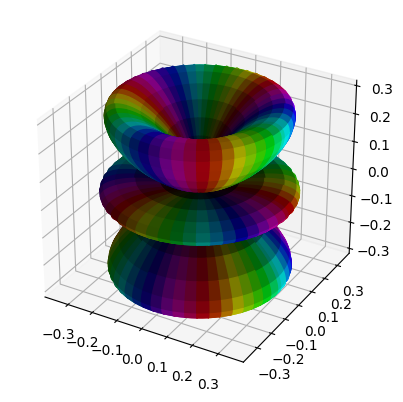

In [5]:
fig, ax = plt.subplots(subplot_kw=dict(projection='3d'))

theta = np.linspace(0, 2 * np.pi, 100)
phi = np.linspace(0, np.pi, 350)

theta, phi = np.meshgrid(theta, phi)

F = sph_harm(3, 5, theta, phi)

r = np.abs(F)
c = np.angle(F)

x = r * np.sin(phi) * np.cos(theta)
y = r * np.sin(phi) * np.sin(theta)
z = r * np.cos(phi)


def complex_array_to_rgb(X, theme='dark', rmax=None):
    '''Takes an array of complex number and converts it to an array of [r, g, b],
    where phase gives hue and saturaton/value are given by the absolute value.
    Especially for use with imshow for complex plots.'''
    absmax = rmax or np.abs(X).max()
    Y = np.zeros(X.shape + (3,), dtype='float')
    Y[..., 0] = np.angle(X) / (2 * np.pi) % 1
    if theme == 'light':
        Y[..., 1] = np.clip(np.abs(X) / absmax, 0, 1)
        Y[..., 2] = 1
    elif theme == 'dark':
        Y[..., 1] = 1
        Y[..., 2] = np.clip(np.abs(X) / absmax, 0, 1)
    Y = hsv_to_rgb(Y)
    return Y


ax.plot_surface(x, y, z, facecolors=complex_array_to_rgb(F))
ax.set_box_aspect((np.ptp(x), np.ptp(y), np.ptp(z)))

None

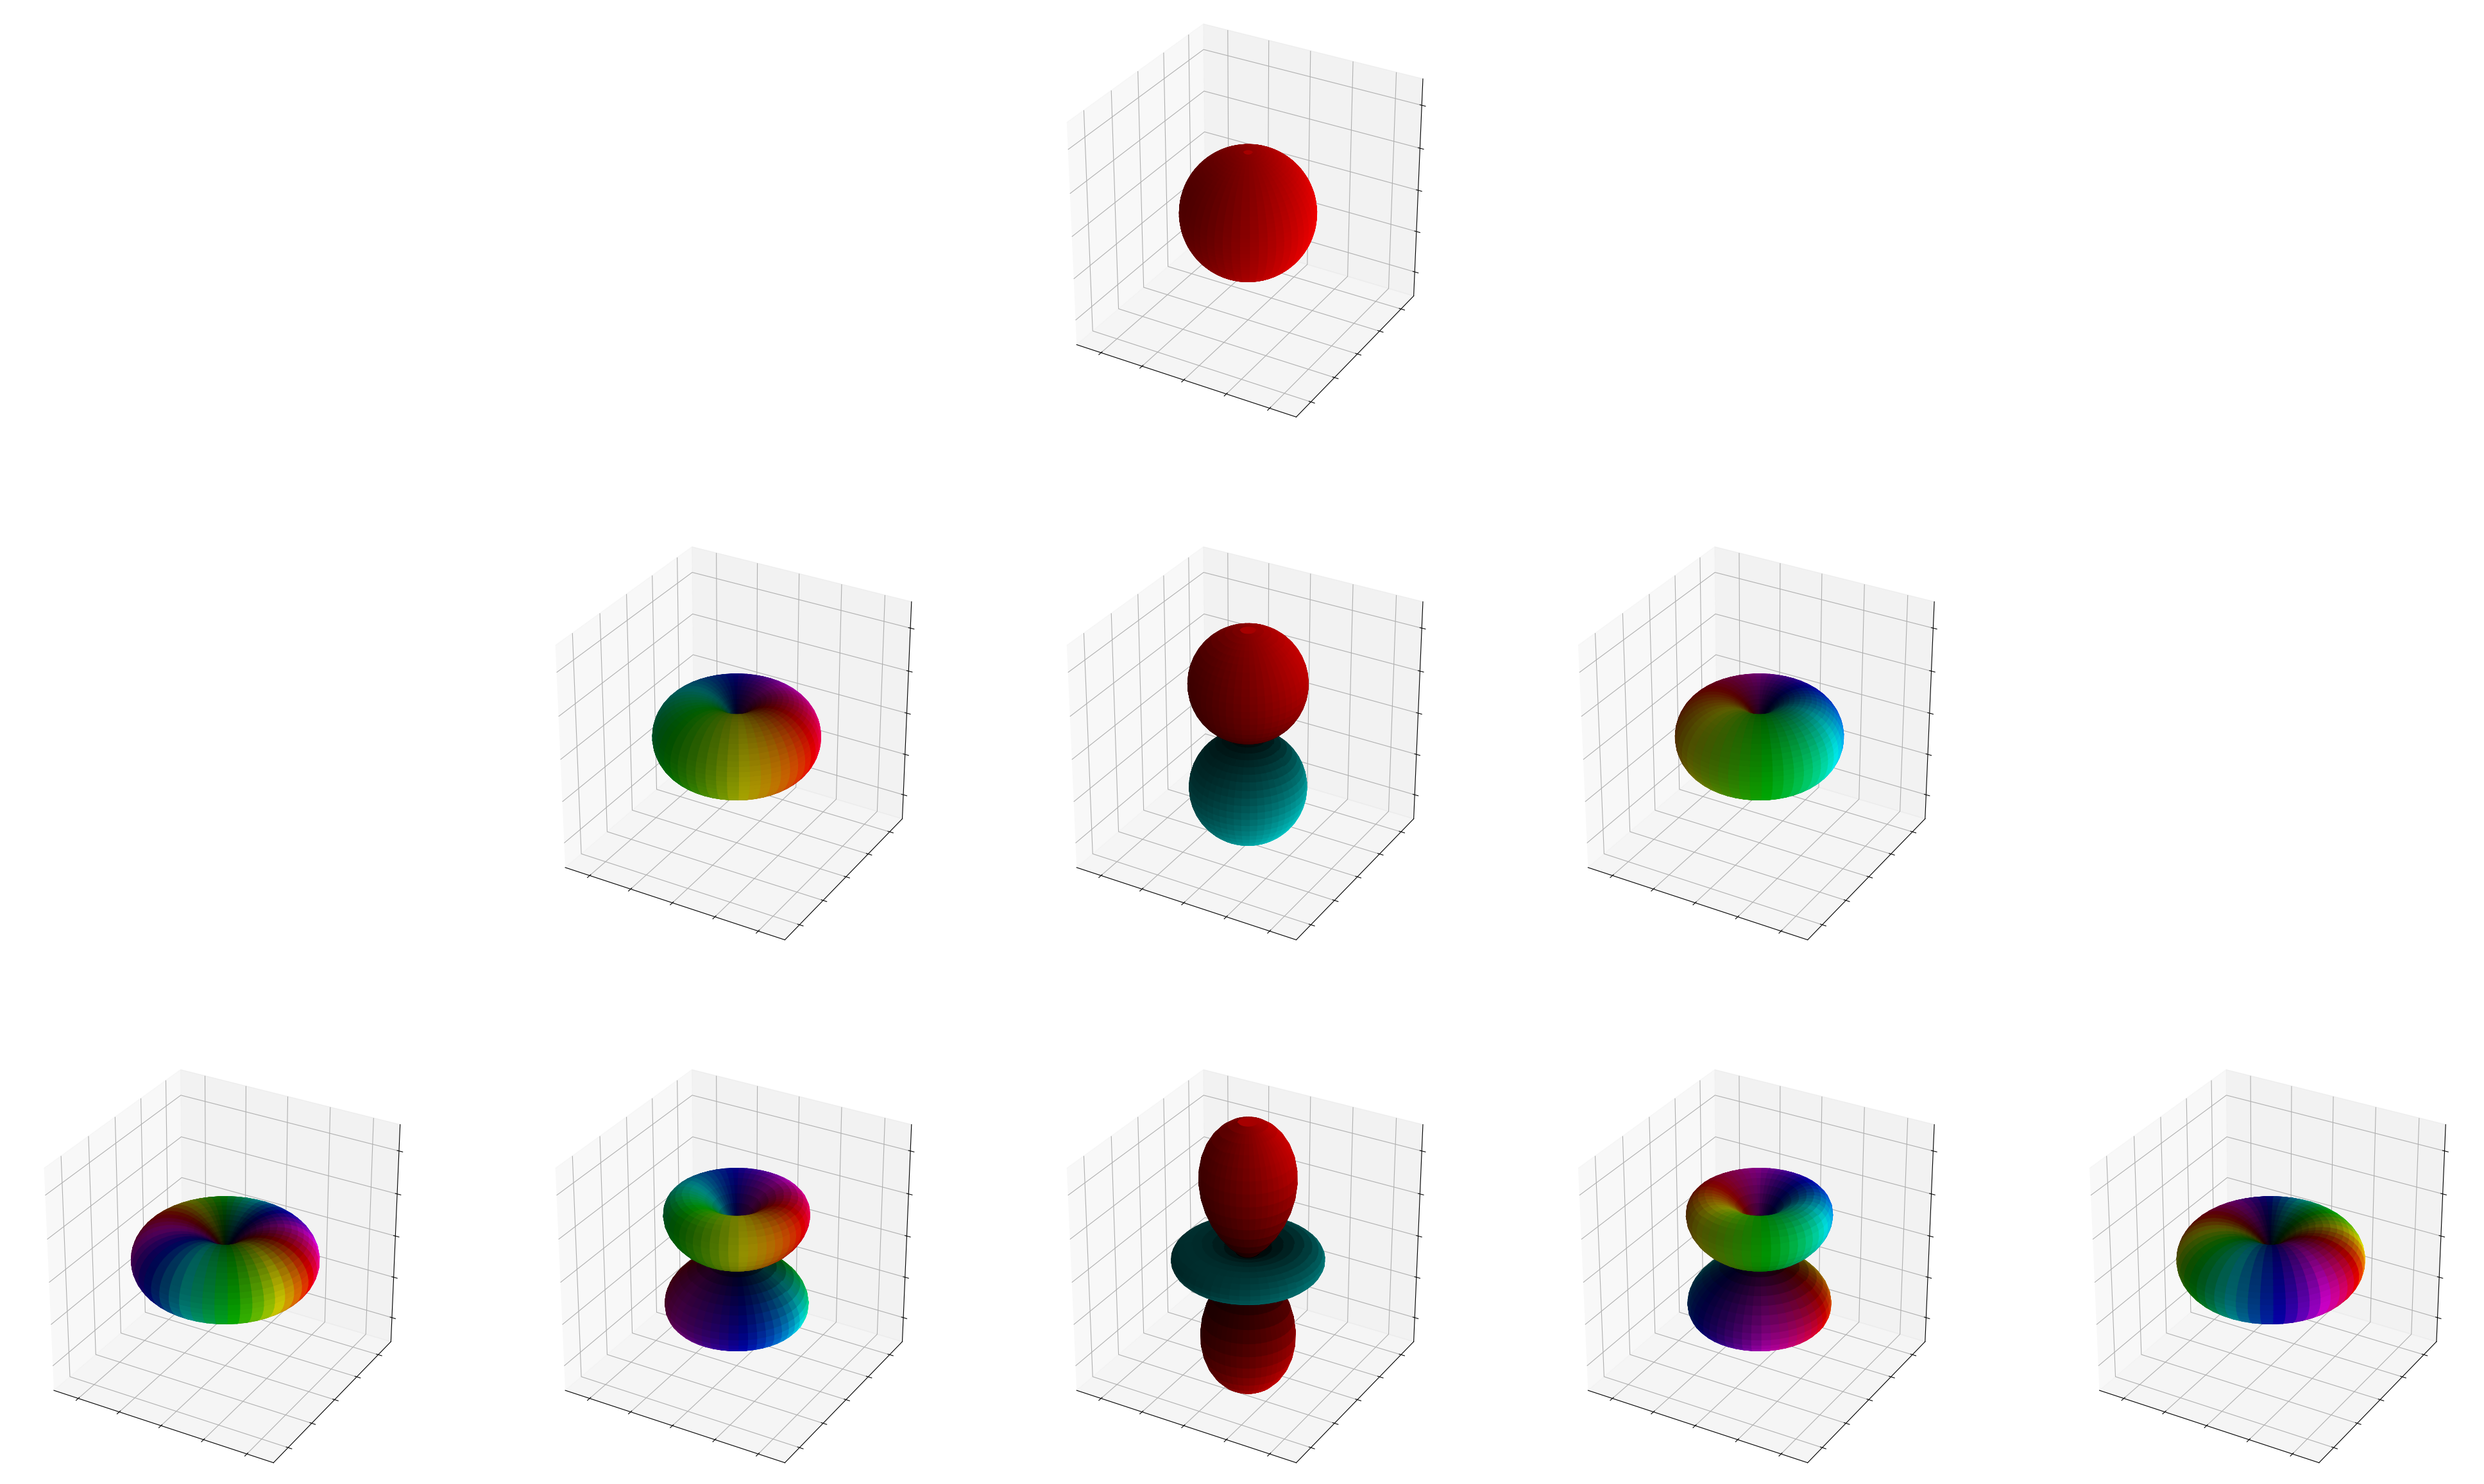

In [11]:
COUNT = 3

fig = plt.figure(figsize=(COUNT * 2 * 10, COUNT * 10), dpi=100)

theta = np.linspace(0, 2 * np.pi, 50)
phi = np.linspace(0, np.pi, 50)

theta, phi = np.meshgrid(theta, phi)

for m in range(COUNT):
    for l in range(-m, m + 1):
        ax = plt.subplot2grid((COUNT, COUNT * 2), (m, l + COUNT), 1, 1, projection='3d')
        ax.set_xlim3d(-0.5, 0.5)
        ax.set_ylim3d(-0.5, 0.5)
        ax.set_zlim3d(-0.5, 0.5)
        ax.xaxis.set_ticklabels([])
        ax.yaxis.set_ticklabels([])
        ax.zaxis.set_ticklabels([])
        ax.set_box_aspect((1, 1, 1))

        F = sph_harm(l, m, theta, phi)

        r = np.abs(F)

        x = r * np.sin(phi) * np.cos(theta)
        y = r * np.sin(phi) * np.sin(theta)
        z = r * np.cos(phi)

        ax.plot_surface(x, y, z, facecolors=complex_array_to_rgb(F))

In [31]:
fig.savefig('out.svg')